**Import packages and dependecies**

In [1]:
%pip install -q -e ..

Note: you may need to restart the kernel to use updated packages.


ERROR: file:///C:/Users/tcphan/OneDrive/Documents/Data%20Science%20Projects/topological does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from tda.rips import VietorisRips
from tda.plotting import plot_barcode, plot_persistence_diagram
from tda.distance import bottleneck_distance, wasserstein_distance

**Calculating Vietoris Rips Simplex:**

In [3]:
n_records = 10 # Number of records or rows
m_columns = 5 # Number of dimensions or columns

# Initialize seed value
rng = np.random.default_rng(seed=42)

# Creating a sample DataFrame
df = pl.DataFrame({
        f"feature_{m}": rng.normal(loc=0.0, scale=1.0, size=n_records) for m in range(m_columns)
    })

# Find all Rips simplices
n_dimensions = 2
rips_config = VietorisRips(max_dim=n_dimensions,)
rips_config.fit_transform(df)

# Retrieve all simplices
all_simplices = rips_config.get_all_simplices()
print(f"Total # of simplices: {len(all_simplices)}")

for i in range(n_dimensions+1):

    print(f"\n{i}-dimensional simplices (simplex_tuple, birth_time)")
    print("-"*100)

    simplices = rips_config.get_simplices_for_dim(dim=i)
    for j in simplices:
        print(j)

Total # of simplices: 175

0-dimensional simplices (simplex_tuple, birth_time)
----------------------------------------------------------------------------------------------------
((1,), 0.0)
((2,), 0.0)
((3,), 0.0)
((4,), 0.0)
((5,), 0.0)
((6,), 0.0)
((7,), 0.0)
((8,), 0.0)
((9,), 0.0)
((0,), 0.0)

1-dimensional simplices (simplex_tuple, birth_time)
----------------------------------------------------------------------------------------------------
((6, 8), 0.9148407868258831)
((3, 8), 1.2247182736454651)
((5, 9), 1.3120578709342055)
((4, 9), 1.48831122801254)
((1, 4), 1.4890475908958767)
((6, 9), 1.5422127730086728)
((1, 8), 1.564078737720856)
((4, 5), 1.5686900734164289)
((3, 6), 1.6143091942024475)
((6, 7), 1.7131058090054256)
((1, 6), 1.7878418248624275)
((1, 9), 1.8164498372466262)
((7, 9), 1.8344771990661057)
((2, 6), 1.8645436722509245)
((7, 8), 1.9170951413088222)
((2, 8), 1.951783482632528)
((2, 7), 1.954721010001166)
((2, 3), 1.9888108407962228)
((8, 9), 2.027581004754788)
(

**Compute Birth-Death Pairs**

In [4]:
birth_death_by_dimension = rips_config.compute_birth_death_pairs()
for dimension, birth_death_pairs in birth_death_by_dimension.items():

    print(f"\n{dimension}-th Dimension")
    print("-"*100)
    for pair in birth_death_pairs:
        print(pair)


0-th Dimension
----------------------------------------------------------------------------------------------------
(0.0, 1.4890475908958767)
(0.0, 1.8645436722509245)
(0.0, 1.2247182736454651)
(0.0, 1.48831122801254)
(0.0, 1.3120578709342055)
(0.0, 0.9148407868258831)
(0.0, 1.7131058090054256)
(0.0, 1.5422127730086728)
(0.0, 2.2941012927359843)
(0.0, inf)

1-th Dimension
----------------------------------------------------------------------------------------------------
(1.564078737720856, 1.7878418248624275)
(1.7878418248624275, 1.8164498372466262)


**Persistence Barcode Plot of Rips Simplices**

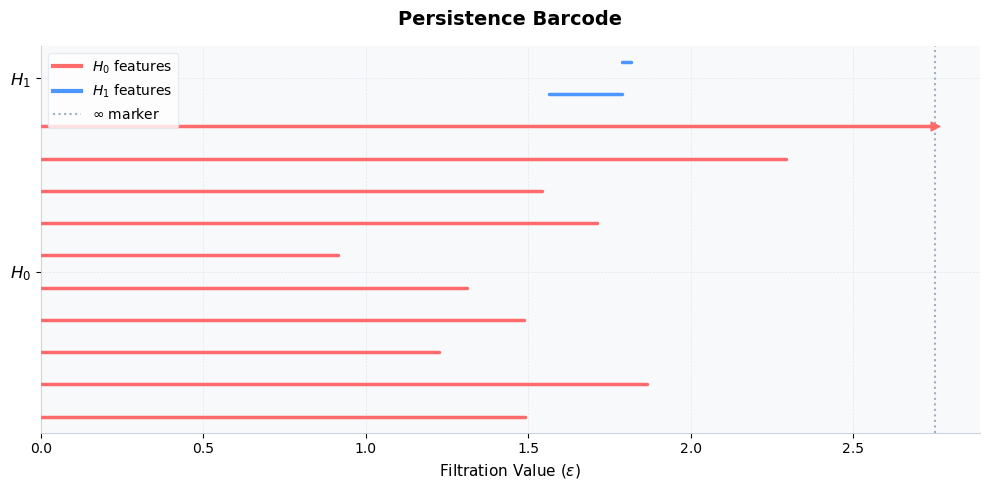

In [5]:
# Plot a persistence barcode plot showcasing the birth and death time of each simplex in each dimension
fig, ax = plt.subplots(figsize=(10, 5)) 
plot_barcode(intervals=birth_death_by_dimension, max_limit=None, ax=ax, show=False)
plt.show()


**Persistence Diagram of Rips Simplices**

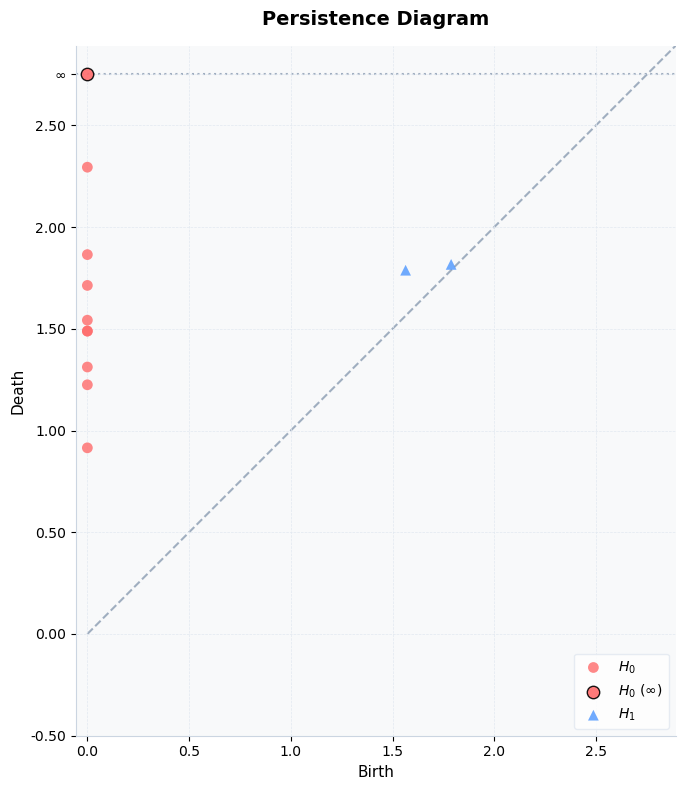

In [6]:
fig, ax = plt.subplots(figsize=(8,8)) 
plot_persistence_diagram(intervals=birth_death_by_dimension, max_limit=None, ax=ax, show=False)
plt.show()

**Calculate Bottleneck/Wasserstein Distance Between Persistence Diagrams**

In [7]:
n_records = 10 # Number of records or rows
m_columns = 5 # Number of dimensions or columns

# Creating a sample DataFrame
df1 = pl.DataFrame({
        f"feature_{m}": np.random.normal(loc=0.0, scale=1.0, size=n_records) for m in range(m_columns)
    })
df2 = pl.DataFrame({
        f"feature_{m}": np.random.normal(loc=5.0, scale=10.0, size=n_records) for m in range(m_columns)
    })

# Fit Rips simplices
n_dimensions = 2
rips_config1 = VietorisRips(max_dim=n_dimensions,)
rips_config1.fit_transform(df1)

rips_config2 = VietorisRips(max_dim=n_dimensions,)
rips_config2.fit_transform(df2)

# Find persistence pairs
birth_death_by_dimension1 = rips_config1.compute_birth_death_pairs()
birth_death_by_dimension2 = rips_config2.compute_birth_death_pairs()

# Convert to list of tuples format
birth_death_pairs_list1 = [pair for pairs_list in birth_death_by_dimension1.values() for pair in pairs_list if pair[1] != np.inf]
birth_death_pairs_list2 =  [pair for pairs_list in birth_death_by_dimension2.values() for pair in pairs_list if pair[1] != np.inf]

# Calculate distances between persistence diagrams
b_distance = bottleneck_distance(diagram_a=birth_death_pairs_list1, diagram_b=birth_death_pairs_list2)
w_distance = wasserstein_distance(diagram_a=birth_death_pairs_list1, diagram_b=birth_death_pairs_list2, p=2.0, l_distance_metric="l_inf")
print(f"Bottleneck distance: {b_distance}")
print(f"Wasserstein distance: {w_distance}")

Bottleneck distance: 11.340966452942943
Wasserstein distance: 28.05154306480253
